# AI-Generated Image Detection Using DIP and Machine Learning

This notebook detects real vs AI-generated images using handcrafted image processing features and an SVM classifier.


## 1. Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import kagglehub

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, roc_auc_score
)

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

np.random.seed(42)


## 2. Load Dataset

In [2]:
dataset_path = kagglehub.dataset_download("birdy654/cifake-real-and-ai-generated-synthetic-images")

train_path = os.path.join(dataset_path, "train")
fake_path = os.path.join(train_path, "FAKE")
real_path = os.path.join(train_path, "REAL")

print("Dataset path:", dataset_path)
print("Train folders:", os.listdir(train_path))
print("FAKE images:", len(os.listdir(fake_path)))
print("REAL images:", len(os.listdir(real_path)))


Using Colab cache for faster access to the 'cifake-real-and-ai-generated-synthetic-images' dataset.
Dataset path: /kaggle/input/cifake-real-and-ai-generated-synthetic-images
Train folders: ['FAKE', 'REAL']
FAKE images: 50000
REAL images: 50000


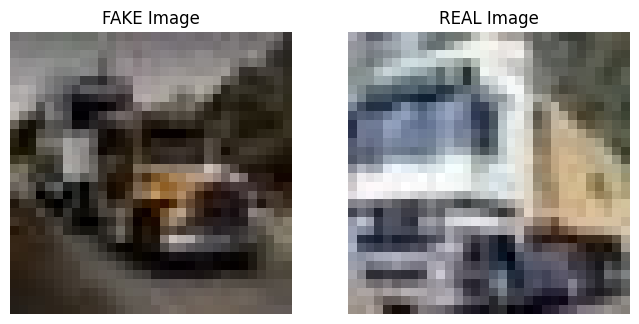

In [3]:
fake_image_path = os.path.join(fake_path, sorted(os.listdir(fake_path))[0])
real_image_path = os.path.join(real_path, sorted(os.listdir(real_path))[0])

fake_img = cv2.cvtColor(cv2.imread(fake_image_path), cv2.COLOR_BGR2RGB)
real_img = cv2.cvtColor(cv2.imread(real_image_path), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(fake_img)
plt.title("FAKE Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(real_img)
plt.title("REAL Image")
plt.axis("off")
plt.show()


## 3. Preprocessing

In [4]:
def preprocess_image(image_path, image_size=(64, 64)):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Image could not be read: {image_path}")

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, image_size)
    gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
    gray_norm = gray / 255.0

    return img_resized, gray_norm


## 4. Feature Extraction

In [5]:
def extract_lbp_features(gray_image, radius=1, n_points=8):
    gray_uint8 = (gray_image * 255).astype(np.uint8)

    lbp = local_binary_pattern(gray_uint8, n_points, radius, method="uniform")

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_points + 3),
        range=(0, n_points + 2)
    )

    hist = hist.astype("float")
    hist /= (hist.sum() + 1e-6)

    return hist


def extract_fft_features(gray_image):
    fft = np.fft.fft2(gray_image)
    fft_shift = np.fft.fftshift(fft)

    magnitude = np.abs(fft_shift)
    power = magnitude ** 2

    h, w = gray_image.shape
    cy, cx = h // 2, w // 2

    y, x = np.ogrid[:h, :w]
    distance = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)

    radius_threshold = min(h, w) * 0.25

    high_freq_energy = power[distance > radius_threshold].sum()
    total_energy = power.sum() + 1e-8
    high_freq_ratio = high_freq_energy / total_energy

    power_norm = power.ravel() / total_energy
    spectral_entropy = -np.sum(power_norm * np.log2(power_norm + 1e-12))

    max_radius = distance.max()
    radial_features = []

    for i in range(4):
        r_min = i * max_radius / 4
        r_max = (i + 1) * max_radius / 4
        band_energy = power[(distance >= r_min) & (distance < r_max)].sum()
        radial_features.append(band_energy / total_energy)

    return np.array([high_freq_ratio, spectral_entropy] + radial_features)


def extract_glcm_features(gray_image):
    gray_uint8 = (gray_image * 255).astype(np.uint8)

    glcm = graycomatrix(
        gray_uint8,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    contrast = graycoprops(glcm, "contrast")[0, 0]
    homogeneity = graycoprops(glcm, "homogeneity")[0, 0]
    energy = graycoprops(glcm, "energy")[0, 0]
    correlation = graycoprops(glcm, "correlation")[0, 0]

    return np.array([contrast, homogeneity, energy, correlation])


def extract_edge_features(gray_image):
    gray_uint8 = (gray_image * 255).astype(np.uint8)

    sobel_x = cv2.Sobel(gray_uint8, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray_uint8, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

    mean_edge = np.mean(magnitude)
    std_edge = np.std(magnitude)
    max_edge = np.max(magnitude)
    edge_density = np.sum(magnitude > 50) / magnitude.size

    return np.array([mean_edge, std_edge, max_edge, edge_density])


def extract_all_features(image_path):
    _, gray = preprocess_image(image_path)

    lbp = extract_lbp_features(gray)
    fft = extract_fft_features(gray)
    glcm = extract_glcm_features(gray)
    edge = extract_edge_features(gray)

    return np.concatenate([lbp, fft, glcm, edge])


## 5. Build Feature Dataset

In [6]:
def create_feature_dataset(fake_dir, real_dir, max_images=500):
    X = []
    y = []

    fake_images = sorted(os.listdir(fake_dir))[:max_images]
    real_images = sorted(os.listdir(real_dir))[:max_images]

    skipped = 0

    for img_name in fake_images:
        try:
            img_path = os.path.join(fake_dir, img_name)
            X.append(extract_all_features(img_path))
            y.append(0)
        except Exception:
            skipped += 1

    for img_name in real_images:
        try:
            img_path = os.path.join(real_dir, img_name)
            X.append(extract_all_features(img_path))
            y.append(1)
        except Exception:
            skipped += 1

    X = np.array(X)
    y = np.array(y)

    print("Skipped images:", skipped)
    return X, y


X, y = create_feature_dataset(fake_path, real_path, max_images=500)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Example feature vector length:", len(X[0]))


Skipped images: 0
Feature matrix shape: (1000, 24)
Label vector shape: (1000,)
Example feature vector length: 24


## 6. Train Baseline SVM

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = SVC(kernel="rbf", C=1, gamma=0.01)
baseline_model.fit(X_train_scaled, y_train)

baseline_pred = baseline_model.predict(X_test_scaled)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))
print("Baseline F1-score:", f1_score(y_test, baseline_pred))


Baseline Accuracy: 0.825
Baseline F1-score: 0.8275862068965517


## 7. Hyperparameter Tuning

In [8]:
param_grid = {
    "kernel": ["linear", "rbf"],
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Accuracy:", grid.best_score_)


Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best Cross-Validation Accuracy: 0.835


## 8. Final Evaluation

In [9]:
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)

print("Final Accuracy:", accuracy_score(y_test, y_pred_best))
print("Final Precision:", precision_score(y_test, y_pred_best))
print("Final Recall:", recall_score(y_test, y_pred_best))
print("Final F1-score:", f1_score(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=["FAKE", "REAL"]))


Final Accuracy: 0.835
Final Precision: 0.8252427184466019
Final Recall: 0.85
Final F1-score: 0.8374384236453202

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.85      0.82      0.83       100
        REAL       0.83      0.85      0.84       100

    accuracy                           0.83       200
   macro avg       0.84      0.83      0.83       200
weighted avg       0.84      0.83      0.83       200



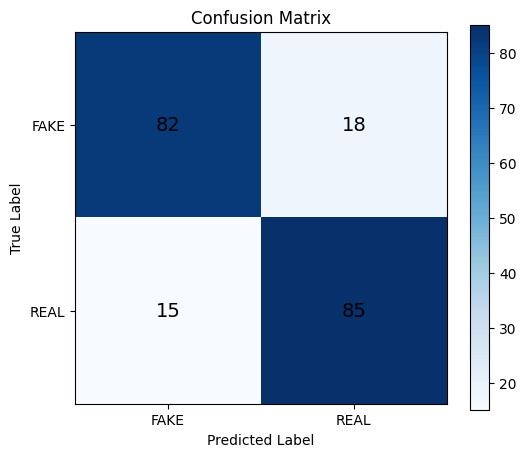

In [10]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

classes = ["FAKE", "REAL"]
plt.xticks([0, 1], classes)
plt.yticks([0, 1], classes)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=14)

plt.show()


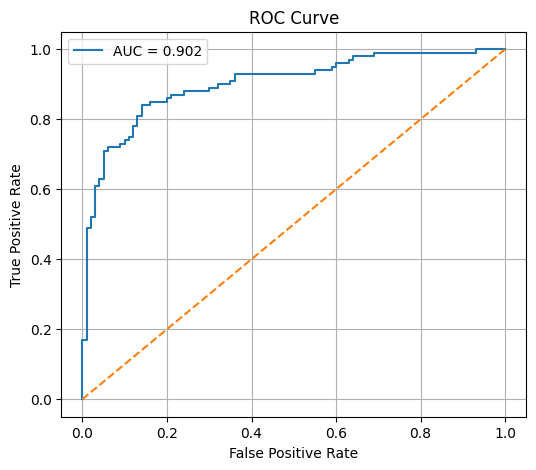

AUC Score: 0.9021


In [11]:
y_scores = best_model.decision_function(X_test_scaled)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc_score = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

print("AUC Score:", auc_score)


## 9. Feature Comparison

In [12]:
def evaluate_feature_set(X_feature, y, feature_name):
    X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
        X_feature, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    scaler_f = StandardScaler()
    X_train_f = scaler_f.fit_transform(X_train_f)
    X_test_f = scaler_f.transform(X_test_f)

    model = SVC(kernel="rbf", C=100, gamma=0.01)
    model.fit(X_train_f, y_train_f)

    y_pred_f = model.predict(X_test_f)

    acc = accuracy_score(y_test_f, y_pred_f)
    f1 = f1_score(y_test_f, y_pred_f)

    print(f"{feature_name}: Accuracy={acc:.4f}, F1={f1:.4f}")
    return acc, f1


X_lbp = X[:, :10]
X_fft = X[:, 10:16]
X_glcm = X[:, 16:20]
X_edge = X[:, 20:24]
X_combined = X

results = {
    "LBP": evaluate_feature_set(X_lbp, y, "LBP Only"),
    "FFT": evaluate_feature_set(X_fft, y, "FFT Only"),
    "GLCM": evaluate_feature_set(X_glcm, y, "GLCM Only"),
    "Edge": evaluate_feature_set(X_edge, y, "Edge Only"),
    "Combined": evaluate_feature_set(X_combined, y, "Combined Features")
}


LBP Only: Accuracy=0.6650, F1=0.6633
FFT Only: Accuracy=0.7000, F1=0.7030
GLCM Only: Accuracy=0.7300, F1=0.7353
Edge Only: Accuracy=0.7350, F1=0.7415
Combined Features: Accuracy=0.8450, F1=0.8394


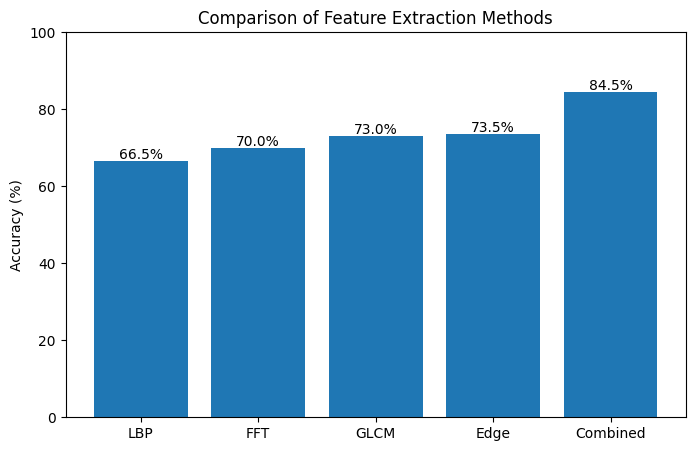

In [13]:
methods = list(results.keys())
accuracies = [results[m][0] * 100 for m in methods]

plt.figure(figsize=(8,5))
bars = plt.bar(methods, accuracies)

plt.ylabel("Accuracy (%)")
plt.title("Comparison of Feature Extraction Methods")
plt.ylim(0, 100)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f"{value:.1f}%",
        ha="center"
    )

plt.show()


## 10. Conclusion

The final model combines FFT, LBP, GLCM, and edge-based features.  
This handcrafted DIP + SVM approach provides an interpretable method for AI-generated image detection.
